In [2]:
from pathlib import Path
import platform
import sys

expected_kernel_name = "langflow-fixed-ORG"
expected_python_version = "3.10.19"
python_version = platform.python_version()
executable_name = Path(sys.executable).name.lower()
executable_path = str(Path(sys.executable)).lower()
kernel_matches = expected_kernel_name.lower() in executable_path or expected_kernel_name.lower() in executable_name
version_matches = python_version == expected_python_version

print(f"Python executable: {sys.executable}")
print(f"Python version: {python_version}")

if not kernel_matches or not version_matches:
    raise RuntimeError(
        "This notebook must run with the 'langflow-fixed-ORG' kernel using Python 3.10.19. "
        f"Current executable: {sys.executable}; current version: {python_version}"
    )

print("Kernel check passed: langflow-fixed-ORG (Python 3.10.19)")

Python executable: c:\Users\PROMET02\anaconda3\envs\langflow-fixed-ORG\python.exe
Python version: 3.10.19
Kernel check passed: langflow-fixed-ORG (Python 3.10.19)


# WILLMA Stress Test V02

This notebook is a simplified reproducibility test for the AI-HUB issues described in the SURF email exchange.

It is designed to answer four practical questions in a way that is easy to explain to a human reader:

1. Does single-user notebook usage work reliably?
2. Can the issue be reproduced with 10 to 20 parallel users?
3. Which HTTP errors appear when failures happen?
4. Does the pattern look more like AI-HUB rate limiting or a client-side problem?

This V02 notebook intentionally avoids advanced scenarios, retry experiments, and many optional branches.

## How To Use This Notebook

Run the notebook from top to bottom.

The notebook performs only three test stages:

- a model discovery check
- a single-user baseline
- a classroom-style stepped concurrency test at 1, 5, 10, 15, and 20 parallel users

At the end, the notebook shows:

- a compact summary table
- readable plots
- a plain-language interpretation block that can be reused in communication with SURF

In [3]:
from pathlib import Path
import concurrent.futures
import platform
import sys
import time
import uuid
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import pandas as pd
import requests

NOTEBOOK_ROOT = Path(r"D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS")
ENV_PATH = NOTEBOOK_ROOT / ".env"
RESULTS_DIR = NOTEBOOK_ROOT / "assets" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_KERNEL = "langflow-fixed-ORG"
EXPECTED_PYTHON = "3.10.19"

WILLMA_DISCOVERY_URL = "https://api.willma.surf.nl/v0/sequences"
WILLMA_CHAT_URL = "https://willma.surf.nl/api/v0/chat/completions"

CONCURRENCY_LEVELS = [1, 5, 10, 15, 20]
REQUESTS_PER_LEVEL = 10
CONNECT_TIMEOUT_SECONDS = 15
READ_TIMEOUT_SECONDS = 90
TEMPERATURE = 0.2
MAX_TOKENS = 300

TEST_PROMPT = (
    "Explain in simple markdown what WiLLMa / the SURF AI-HUB is, "
    "why single-user success does not prove classroom-scale reliability, "
    "and why concurrency can trigger rate limits or system errors."
)

python_version = platform.python_version()
executable_path = str(Path(sys.executable)).lower()
kernel_ok = EXPECTED_KERNEL.lower() in executable_path
version_ok = python_version == EXPECTED_PYTHON

print(f"Python executable: {sys.executable}")
print(f"Python version: {python_version}")
if not kernel_ok or not version_ok:
    raise RuntimeError(
        f"Use kernel {EXPECTED_KERNEL} with Python {EXPECTED_PYTHON}. Current: {sys.executable} / {python_version}"
    )

if not ENV_PATH.exists():
    raise FileNotFoundError(f"Missing .env file: {ENV_PATH}")

api_key = None
for raw_line in ENV_PATH.read_text(encoding="utf-8").splitlines():
    line = raw_line.strip()
    if not line or line.startswith("#") or "=" not in line:
        continue
    key, value = line.split("=", 1)
    if key.strip() == "api_key":
        api_key = value.strip().strip("\"'")
        break

if not api_key:
    raise ValueError(f"No api_key found in {ENV_PATH}")

def mask_secret(value: str, prefix: int = 12, suffix: int = 4) -> str:
    if len(value) <= prefix + suffix:
        return value
    return f"{value[:prefix]}...{value[-suffix:]}"

HEADERS = {"X-API-KEY": api_key, "Content-Type": "application/json"}
print(f"API key loaded: {mask_secret(api_key)}")
print(f"Results directory: {RESULTS_DIR}")

Python executable: c:\Users\PROMET02\anaconda3\envs\langflow-fixed-ORG\python.exe
Python version: 3.10.19
API key loaded: 77696c6c6d61...856e
Results directory: D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\results


## Step 1: Discover Available Models

This step confirms that the API key works and shows which text models are available for testing.

The notebook will prefer a Mistral model when available, because that has been the most useful default in earlier tests.

In [4]:
def discover_models() -> tuple[pd.DataFrame, list[str]]:
    response = requests.get(
        WILLMA_DISCOVERY_URL,
        headers=HEADERS,
        timeout=(CONNECT_TIMEOUT_SECONDS, READ_TIMEOUT_SECONDS),
    )
    print(f"Model discovery status: {response.status_code}")
    response.raise_for_status()
    payload = response.json()
    if not isinstance(payload, list):
        raise ValueError(f"Expected list from discovery endpoint, got {type(payload).__name__}")
    df = pd.DataFrame(payload)
    if "sequence_type" not in df.columns:
        df["sequence_type"] = "unknown"
    text_models = [
        row["name"]
        for _, row in df.iterrows()
        if str(row.get("sequence_type", "")).lower() == "text" and row.get("name")
    ]
    preferred = sorted(
        text_models,
        key=lambda name: (0 if "mistral" in name.lower() else 1, name.lower())
    )
    return df, preferred

models_df, text_models = discover_models()
display(models_df[[col for col in ["id", "name", "sequence_type", "latency_mode"] if col in models_df.columns]])
print("\nCandidate text models:")
for model_name in text_models:
    print(f"- {model_name}")

if not text_models:
    raise ValueError("No text models discovered for testing.")

selected_model = text_models[0]
print(f"\nSelected model for V02: {selected_model}")

Model discovery status: 200


,id,name,sequence_type,latency_mode
0,42,meta-llama/Llama-Guard-3-8B,text,on-demand
1,44,mistralai/Mistral-Small-3.2-24B-Instruct-2506,text,always-on



Candidate text models:
- mistralai/Mistral-Small-3.2-24B-Instruct-2506
- meta-llama/Llama-Guard-3-8B

Selected model for V02: mistralai/Mistral-Small-3.2-24B-Instruct-2506


## Step 2: Define One Simple Request Function

This notebook uses one request function without retries.

That is intentional: if failures happen, we want to see the raw HTTP behavior directly instead of hiding it behind retry logic.

In [5]:
def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

def classify_status(http_status: int | None, exception_type: str | None) -> str:
    if exception_type == "timeout":
        return "timeout"
    if exception_type == "request_error":
        return "request_error"
    if http_status is None:
        return "unknown"
    if 200 <= http_status < 300:
        return "success"
    if http_status == 429:
        return "rate_limited"
    if http_status in (401, 403):
        return "not_authorized"
    if http_status == 404:
        return "not_found"
    if 500 <= http_status < 600:
        return "server_error"
    return f"http_{http_status}"

def run_one_request(model_name: str, prompt_text: str, concurrency_level: int, request_number: int) -> dict:
    payload = {
        "model": model_name,
        "messages": [
            {"role": "system", "content": "You are a concise assistant."},
            {"role": "user", "content": prompt_text},
        ],
        "temperature": TEMPERATURE,
        "max_tokens": MAX_TOKENS,
        "stream": False,
    }

    started = time.perf_counter()
    response = None
    exception_type = None
    error_text = ""

    try:
        response = requests.post(
            WILLMA_CHAT_URL,
            headers=HEADERS,
            json=payload,
            timeout=(CONNECT_TIMEOUT_SECONDS, READ_TIMEOUT_SECONDS),
        )
        if not response.ok:
            error_text = response.text[:300]
    except requests.Timeout as exc:
        exception_type = "timeout"
        error_text = str(exc)
    except requests.RequestException as exc:
        exception_type = "request_error"
        error_text = str(exc)

    latency_seconds = round(time.perf_counter() - started, 4)
    http_status = None if response is None else response.status_code

    return {
        "timestamp_utc": utc_now_iso(),
        "request_id": uuid.uuid4().hex,
        "model": model_name,
        "concurrency_level": concurrency_level,
        "request_number": request_number,
        "http_status": http_status,
        "status": classify_status(http_status, exception_type),
        "latency_seconds": latency_seconds,
        "retry_after": None if response is None else response.headers.get("Retry-After"),
        "error_text": error_text,
    }

## Step 3: Run The Reproducibility Tests

This step runs two simple tests:

- a single-user baseline at concurrency 1
- a stepped classroom test at 1, 5, 10, 15, and 20 parallel users

Each level sends the same number of requests per user group so the results stay easy to compare.

In [6]:
def run_level(model_name: str, concurrency_level: int, requests_per_level: int) -> pd.DataFrame:
    with concurrent.futures.ThreadPoolExecutor(max_workers=concurrency_level) as executor:
        futures = [
            executor.submit(run_one_request, model_name, TEST_PROMPT, concurrency_level, request_number)
            for request_number in range(1, requests_per_level + 1)
        ]
        rows = [future.result() for future in concurrent.futures.as_completed(futures)]
    return pd.DataFrame(rows).sort_values(by="request_number").reset_index(drop=True)

all_results = []
for level in CONCURRENCY_LEVELS:
    print(f"Running level {level} with {REQUESTS_PER_LEVEL} requests...")
    level_df = run_level(selected_model, level, REQUESTS_PER_LEVEL)
    all_results.append(level_df)

results_df = pd.concat(all_results, ignore_index=True)
display(results_df.head(10))
print(f"\nTotal requests executed: {len(results_df)}")

Running level 1 with 10 requests...
Running level 5 with 10 requests...
Running level 10 with 10 requests...
Running level 15 with 10 requests...
Running level 20 with 10 requests...


,timestamp_utc,request_id,model,concurrency_level,request_number,http_status,status,latency_seconds,retry_after,error_text
0,2026-08-04T20:41:36.917305+00:00,e87564220ace461e8e7661d4c5ed7cac,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,1,200,success,10.1009,None,
1,2026-08-04T20:41:47.591691+00:00,15562fa0de1a4d3981dd22fc0861fd23,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,2,200,success,10.6724,None,
2,2026-08-04T20:41:59.111772+00:00,6a301d6f2c6a49dfafff5b9f1270d08c,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,3,200,success,11.5208,None,
3,2026-08-04T20:42:09.900981+00:00,de368a05961d4d87adca16a1c6ce41d4,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,4,200,success,10.7858,None,
4,2026-08-04T20:42:19.834947+00:00,6a99f3cbfd1546dbba8c490e05eb83de,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,5,200,success,9.9319,None,
5,2026-08-04T20:42:29.746137+00:00,6e0e29a08bfd479e8c6e737e2ee9d109,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,6,200,success,9.9100,None,
6,2026-08-04T20:42:40.629882+00:00,0e3287f2d434466b90e467d90ebe90a8,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,7,200,success,10.8815,None,
7,2026-08-04T20:42:50.891699+00:00,471f2960b35f4a24bc4a29e4a500408e,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,8,200,success,10.2608,None,
8,2026-08-04T20:43:01.782177+00:00,e1b8865bb66042f394a60704ee97aaf9,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,9,200,success,10.8883,None,
9,2026-08-04T20:43:13.193469+00:00,0948ba8fb42349db87951f24a29535f8,mistralai/Mistral-Small-3.2-24B-Instruct-2506,1,10,200,success,11.4115,None,



Total requests executed: 50


## Step 4: Build A Human-Readable Summary

The summary below is intentionally small.

It focuses on the metrics that matter most for the email discussion with SURF:

- how many requests succeeded
- how many were rate limited
- how many timed out
- which HTTP errors appeared
- how latency changed as concurrency increased

In [7]:
def summarize_level(level_df: pd.DataFrame) -> dict:
    latencies = level_df["latency_seconds"].dropna().tolist()
    return {
        "concurrency_level": int(level_df["concurrency_level"].iloc[0]),
        "total_requests": int(len(level_df)),
        "success_count": int((level_df["status"] == "success").sum()),
        "rate_limited_count": int((level_df["status"] == "rate_limited").sum()),
        "timeout_count": int((level_df["status"] == "timeout").sum()),
        "server_error_count": int((level_df["status"] == "server_error").sum()),
        "other_error_count": int((~level_df["status"].isin(["success", "rate_limited", "timeout", "server_error"])).sum()),
        "success_rate": round((level_df["status"] == "success").mean(), 3),
        "avg_latency_seconds": round(sum(latencies) / len(latencies), 3) if latencies else None,
        "max_latency_seconds": round(max(latencies), 3) if latencies else None,
        "http_errors_seen": ", ".join(sorted({str(value) for value in level_df["http_status"].dropna().tolist() if int(value) >= 400})) or "none",
    }

summary_df = pd.DataFrame([summarize_level(group) for _, group in results_df.groupby("concurrency_level")])
summary_df = summary_df.sort_values(by="concurrency_level").reset_index(drop=True)
display(summary_df)

,concurrency_level,total_requests,success_count,rate_limited_count,timeout_count,server_error_count,other_error_count,success_rate,avg_latency_seconds,max_latency_seconds,http_errors_seen
0,1,10,10,0,0,0,0,1.0,10.636,11.521,none
1,5,10,10,0,0,0,0,1.0,11.047,11.927,none
2,10,10,5,5,0,0,0,0.5,5.686,12.094,429
3,15,10,5,5,0,0,0,0.5,5.745,11.988,429
4,20,10,5,5,0,0,0,0.5,5.578,12.116,429


## Step 5: Plot The Results

These plots are intentionally simple:

- Plot 1 shows success rate by concurrency
- Plot 2 shows the number of rate-limited and timeout responses
- Plot 3 shows average and maximum latency

Together they make it easy to see whether the problem starts only when many users work in parallel.

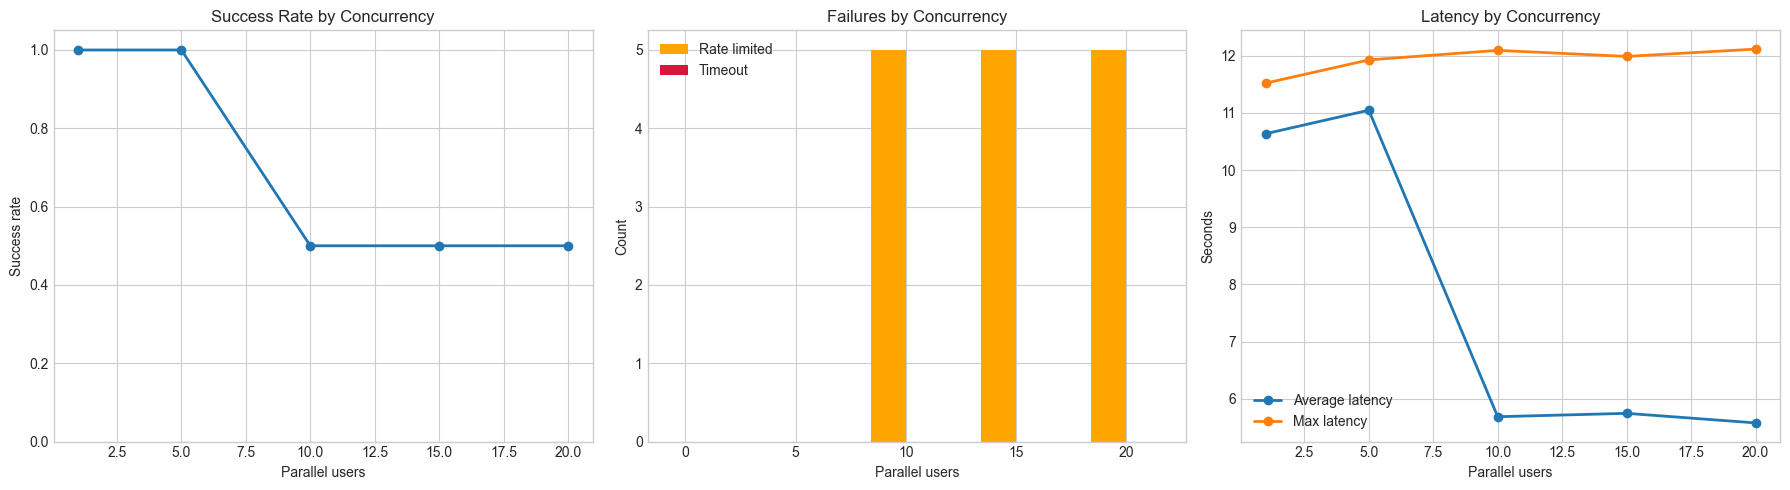

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(summary_df["concurrency_level"], summary_df["success_rate"], marker="o", linewidth=2)
axes[0].set_title("Success Rate by Concurrency")
axes[0].set_xlabel("Parallel users")
axes[0].set_ylabel("Success rate")
axes[0].set_ylim(0, 1.05)

axes[1].bar(summary_df["concurrency_level"] - 0.8, summary_df["rate_limited_count"], width=1.6, label="Rate limited", color="orange")
axes[1].bar(summary_df["concurrency_level"] + 0.8, summary_df["timeout_count"], width=1.6, label="Timeout", color="crimson")
axes[1].set_title("Failures by Concurrency")
axes[1].set_xlabel("Parallel users")
axes[1].set_ylabel("Count")
axes[1].legend()

axes[2].plot(summary_df["concurrency_level"], summary_df["avg_latency_seconds"], marker="o", linewidth=2, label="Average latency")
axes[2].plot(summary_df["concurrency_level"], summary_df["max_latency_seconds"], marker="o", linewidth=2, label="Max latency")
axes[2].set_title("Latency by Concurrency")
axes[2].set_xlabel("Parallel users")
axes[2].set_ylabel("Seconds")
axes[2].legend()

plt.tight_layout()
plot_path = RESULTS_DIR / "willma_stress_test_plots.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Saved plot image to {plot_path}")
plt.show()

## Step 6: Plain-Language Conclusion For The SURF Discussion

This final step converts the measured results into a short human-readable interpretation.

The goal is not to prove root cause with certainty, but to make the observed pattern easy to discuss with SURF.

In [9]:
single_user_row = summary_df.loc[summary_df["concurrency_level"] == 1].iloc[0]
high_load_rows = summary_df.loc[summary_df["concurrency_level"] >= 10]

single_user_ok = single_user_row["success_rate"] >= 0.9
high_load_rate_limits = int(high_load_rows["rate_limited_count"].sum())
high_load_timeouts = int(high_load_rows["timeout_count"].sum())
high_load_success_drop = float(high_load_rows["success_rate"].min()) < float(single_user_row["success_rate"])

if high_load_rate_limits > 0:
    likely_interpretation = "The notebook reproduces HTTP 429 rate limiting under higher parallel usage."
elif high_load_timeouts > 0 and high_load_success_drop:
    likely_interpretation = "The notebook reproduces instability under higher parallel usage, but not clearly as HTTP 429 rate limiting."
elif single_user_ok and not high_load_success_drop:
    likely_interpretation = "This run does not reproduce the classroom issue clearly; single-user and parallel usage look similar."
else:
    likely_interpretation = "The notebook shows degraded behavior, but the pattern is mixed and needs follow-up."

conclusion_lines = [
    f"Selected model: {selected_model}",
    f"Single-user success rate: {single_user_row['success_rate']:.3f}",
    f"Total rate-limited responses at concurrency 10-20: {high_load_rate_limits}",
    f"Total timeout responses at concurrency 10-20: {high_load_timeouts}",
    f"Likely interpretation: {likely_interpretation}",
]

print("Conclusion for discussion with SURF:\n")
for line in conclusion_lines:
    print(f"- {line}")

conclusion_df = pd.DataFrame({"statement": conclusion_lines})
display(conclusion_df)

timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
results_df.to_csv(RESULTS_DIR / f"willma_v02_raw_results_{timestamp}.csv", index=False)
summary_df.to_csv(RESULTS_DIR / f"willma_v02_summary_{timestamp}.csv", index=False)
conclusion_df.to_csv(RESULTS_DIR / f"willma_v02_conclusion_{timestamp}.csv", index=False)
print(f"\nSaved CSV outputs to {RESULTS_DIR}")

Conclusion for discussion with SURF:

- Selected model: mistralai/Mistral-Small-3.2-24B-Instruct-2506
- Single-user success rate: 1.000
- Total rate-limited responses at concurrency 10-20: 15
- Total timeout responses at concurrency 10-20: 0
- Likely interpretation: The notebook reproduces HTTP 429 rate limiting under higher parallel usage.


,statement
0,Selected model: mistralai/Mistral-Small-3.2-24...
1,Single-user success rate: 1.000
2,Total rate-limited responses at concurrency 10...
3,Total timeout responses at concurrency 10-20: 0
4,Likely interpretation: The notebook reproduces...



Saved CSV outputs to D:\OneDrive - Hogeschool Rotterdam\SURF_PILOT\AI_HUB_PILOT\WILLMA_STRESS_TESTS\assets\results
